# Sample path plotting — integrated (`make_sample_path` in `symbulate/plot.py`)

This notebook exercises the sample path plot type, now **integrated into the
package** from the approved draft in `team/new_graphics/sample_path.py`. The
`.plot()` methods of `Tuple`, `InfiniteVector`, `DiscreteTimeFunction`, and
`ContinuousTimeFunction` (`symbulate/result.py`) draw through
`make_sample_path()` (`symbulate/plot.py`) instead of the old inline
`plt.plot(ts, ys, ".--")` calls, so every simulated realization plots as a
plain solid line with the package color cycle, axis labels, a title, and an
automatic legend for overlays.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All. The package
applies `symbulate.mplstyle` on import — no manual style setup needed.

**What to look for in every plot:**
- A plain solid connected line — no per-point dot markers, even at 100+
  points
- The first path is sky blue (first Okabe-Ito hue), the second orange, and
  so on — the color cycle advances once per `.plot()` call
- Time-based results label the x-axis "Time"; index-based results
  (`Tuple`, `InfiniteVector`, and `RVResults` ensembles) label it "Index";
  the y-axis reads "Value" and the title "Sample Path"
- A lone path has no legend; separate `.plot()` calls overlaying on the
  same axes get a top-right legend ("Path 1", "Path 2", ... or `label=`
  names)
- One `.plot()` call on *many* simulated realizations draws an ensemble:
  one shared color, alpha fading with the number of paths, and **no**
  legend
- Overlay is **natural** (see CLAUDE.md, "Overlay Policy") — no warning,
  no error

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages).
REPO_ROOT = Path.cwd().parents[2]
sys.path.insert(0, str(REPO_ROOT))

from symbulate import RV, BoxModel, BrownianMotion
from symbulate.plot import (
    SAMPLE_PATH_ALPHA,
    SAMPLE_PATH_LINEWIDTH,
    get_next_color,
    make_sample_path,
)

print(
    f"SAMPLE_PATH_LINEWIDTH = {SAMPLE_PATH_LINEWIDTH}, "
    f"SAMPLE_PATH_ALPHA = {SAMPLE_PATH_ALPHA}"
)

SAMPLE_PATH_LINEWIDTH = 1.5, SAMPLE_PATH_ALPHA = 1.0


## 1. The user-facing API: one realization, one line

A single simulated realization plots itself — no manual `(times, values)`
computation. A `BrownianMotion` realization is a continuous-time function,
so `.plot()` evaluates it on `np.linspace(tmin, tmax, 200)` and the x-axis
reads "Time". One sky-blue solid line, no markers, no legend.

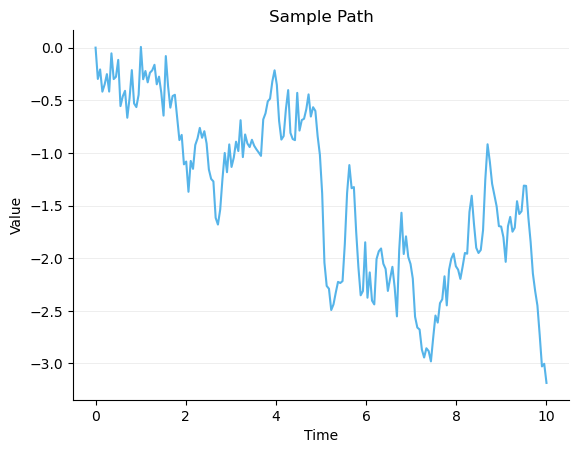

In [2]:
W = BrownianMotion()
w = W.sim(1).get(0)
w.plot()
plt.show()

## 2. Overlay — separate `.plot()` calls in one cell

Natural overlay: a second call draws on top of the first with the next
Okabe-Ito color, and the legend appears automatically, naming paths
"Path 1", "Path 2", ... in call order.

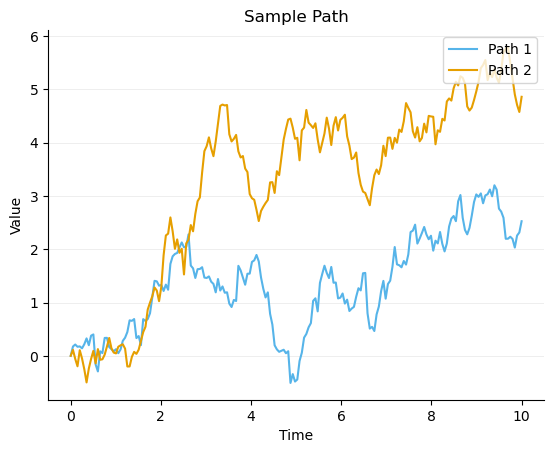

In [3]:
sims = W.sim(2)
sims.get(0).plot()
sims.get(1).plot()
plt.show()

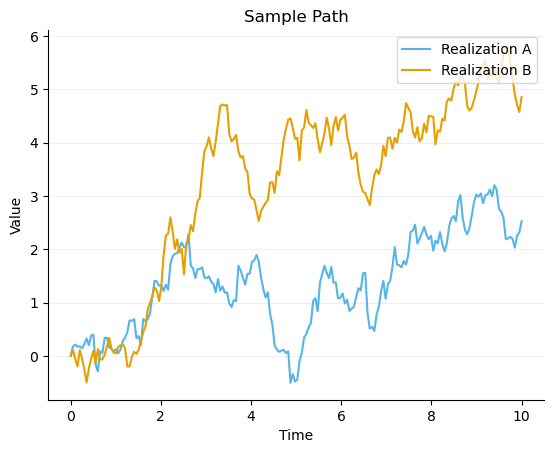

In [4]:
# label= replaces the automatic "Path k" names.
sims.get(0).plot(label="Realization A")
sims.get(1).plot(label="Realization B")
plt.show()

## 3. Ensembles — many realizations in one `.plot()` call

Plotting a whole batch of simulations goes through `RVResults.plot()`,
which draws every realization in **one shared color** with alpha fading as
the batch grows, so the ensemble reads as a distribution over paths. The
per-path "Path k" legend entries are suppressed (they would be meaningless
for 50 same-colored lines), and the x-axis reads "Index" — both unchanged
from the pre-integration behavior.

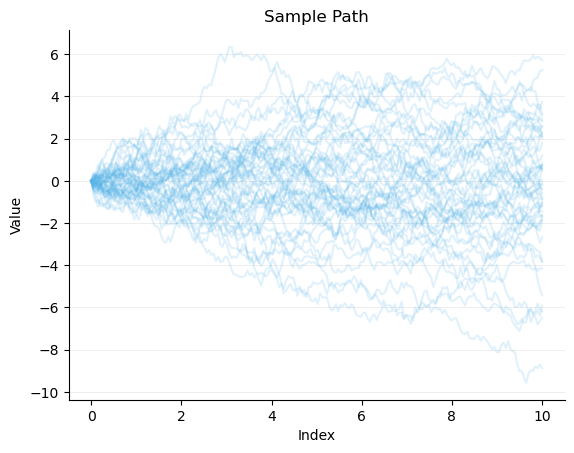

In [5]:
W.sim(50).plot()
plt.show()

## 4. Index-based results

A finite realization — here a 100-step random walk built by simulating
±1 steps from a `BoxModel` RV and taking the cumulative sum — plots over
its index, so the x-axis reads "Index" instead of "Time".

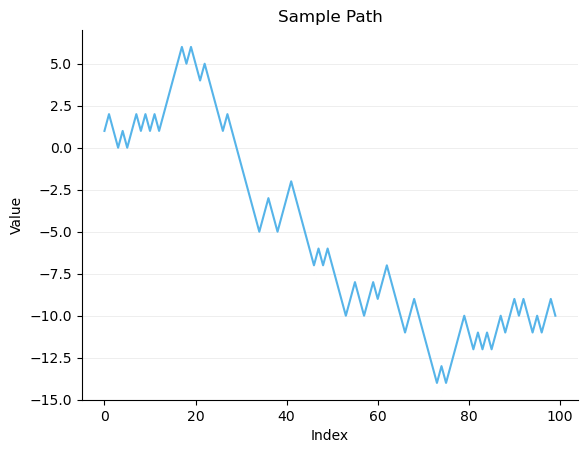

In [6]:
steps = RV(BoxModel([-1, 1], size=100, replace=True)).sim(1).get(0)
steps.cumsum().plot()
plt.show()

## 5. Options, and the helper itself

Keyword arguments pass through `.plot()` to `make_sample_path`:
`xlabel=`/`ylabel=` override the axis labels (naming per CLAUDE.md: no
underscore), `linewidth=` and `alpha=` override the package constants, and
anything else goes to `ax.plot`. The helper can also be called directly
with hand-made data, exactly like the other `make_*` helpers in
`symbulate/plot.py`.

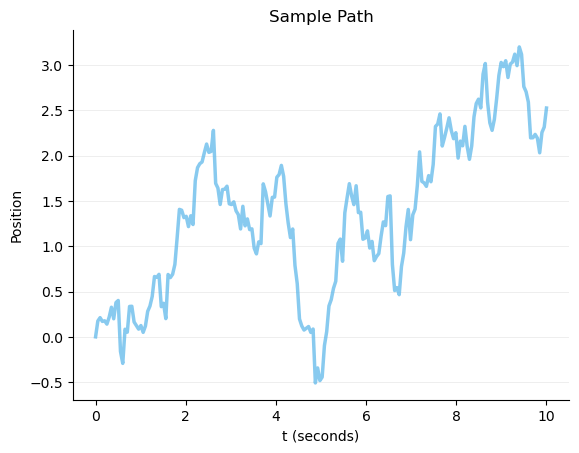

In [7]:
sims.get(0).plot(
    xlabel="t (seconds)",
    ylabel="Position",
    linewidth=2.5,
    alpha=0.7,
)
plt.show()

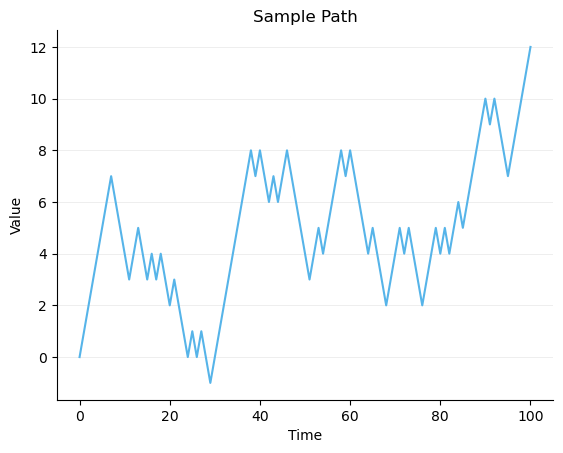

In [8]:
# The draft's original prototype figure, via the integrated helper.
rng = np.random.default_rng(7)
n = 100
values = np.concatenate([[0], np.cumsum(rng.choice([-1, 1], size=n))])

ax = plt.gca()
make_sample_path(np.arange(n + 1), values, ax, get_next_color(ax))
plt.show()

## Verification checklist

- [ ] Section 1: a lone sky-blue solid line, no per-point markers, no
      legend; x-axis "Time", y-axis "Value", title "Sample Path"
- [ ] Section 2: overlays draw with no warning or error (natural overlay),
      each path in the next Okabe-Ito color, legend in the top right with
      "Path 1"/"Path 2" or the `label=` names
- [ ] Section 3: an ensemble (`W.sim(50).plot()`) draws all paths in one
      shared color with faded alpha, **no** legend, x-axis "Index"
- [ ] Section 4: index-based results label the x-axis "Index"
- [ ] Section 5: `xlabel=`/`ylabel=`, `linewidth=`, and `alpha=` overrides
      all take effect; `make_sample_path` works directly with hand-made
      data